# Скоринг по анкете клиента

Home Credit Default Risk, 307 511 заявок. `TARGET = 1` - платёжные трудности.

Цель: скоркарта на полях, которые клиент вводит сам, с объяснимым отказом.

Исключены все признаки, которые клиент не знает и не имеет доступа

Модель: логрегрессия на WOE. Вклад признака = `коэф · WOE`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
SENTINEL = 365243
RARE_MIN_FREQ = 0.01
IV_THRESHOLD = 0.02

pd.set_option('display.max_info_columns', 500)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#dedddb'
DIVERGING = LinearSegmentedColormap.from_list('corr', [BLUE, '#f2f2f0', ORANGE])
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'axes.titlesize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': GRID, 'grid.linewidth': 0.6,
})

In [2]:
df = pd.read_csv('../datasets/application_train.csv')
print(df.shape, '| дефолтов', f'{df["TARGET"].mean():.2%}', '| дубликатов', df.duplicated().sum())
df.head()

(307511, 122) | дефолтов 8.07% | дубликатов 0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  str    
 3    CODE_GENDER                   307511 non-null  str    
 4    FLAG_OWN_CAR                  307511 non-null  str    
 5    FLAG_OWN_REALTY               307511 non-null  str    
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  str    
 12   NAME_INCOME_TYPE              307511 no

## Чистка

- `DAYS_EMPLOYED = 365243` → `NaN`: заглушка «не применимо», 55 374 строки (пенсионеры)
- `CODE_GENDER = 'XNA'` (4 строки), `NAME_FAMILY_STATUS = 'Unknown'` (2) - ошибки ввода
- пропуски не заполняем: WOE даёт `NaN` отдельную корзину

In [4]:
string_data = df.select_dtypes('str')
for col in string_data.columns:
    print(string_data[col].value_counts(), end='\n\n')

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                  

In [5]:
clean_df = df[(df['CODE_GENDER'] != 'XNA') & (df['NAME_FAMILY_STATUS'] != 'Unknown')].copy()
clean_df.loc[clean_df['DAYS_EMPLOYED'] == SENTINEL, 'DAYS_EMPLOYED'] = np.nan

print('строк', len(clean_df), '| NaN в стаже', clean_df['DAYS_EMPLOYED'].isna().sum())
clean_df.head()

строк 307505 | NaN в стаже 55374


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## Сплит и редкие категории

Сплит до всего, что учится на данных. `keep` считается по train, применяется к обеим частям.
Порог 1% - иначе корзина из нескольких наблюдений даёт огромный WOE.

In [6]:
X = clean_df.drop(columns=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                           'TARGET', 'SK_ID_CURR'])
y = clean_df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y, shuffle=True)

cat_cols = [c for c in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[c])]

keep = {}
for col in cat_cols:
    freq = X_train[col].value_counts(normalize=True)
    keep[col] = set(freq.index[freq >= RARE_MIN_FREQ])

def collapse(s, keep_set):
    return s.where(s.isin(keep_set) | s.isna(), 'OTHER')

for col in cat_cols:
    X_train[col] = collapse(X_train[col], keep[col])
    X_val[col] = collapse(X_val[col], keep[col])

print('train', X_train.shape, '| val', X_val.shape)

train (230628, 117) | val (76877, 117)


## WOE и IV


$$WOE = ln(\frac{good \%}{bad \%})$$
$$IV  = \sum_{i} (good\% - bad\%) * ln(\frac{good\%}{bad\%})$$


Границы корзин считаются на train и переиспользуются на val.

In [7]:
MISSING = 'MISSING'


class WoEEncoder:

    def __init__(self, bins=10, smooth=0.5, unseen_woe=0.0):
        self.bins = bins
        self.smooth = smooth
        self.unseen_woe = unseen_woe

    def _is_numeric(self, s):
        return pd.api.types.is_numeric_dtype(s) and s.nunique() > self.bins

    def _to_bins(self, s, col):
        if self.numeric_[col]:
            b = pd.cut(s, bins=self.edges_[col]).astype('object')
        else:
            b = s.astype('object')
        return b.where(s.notna(), MISSING).astype('str')

    def fit(self, X, y):
        y = pd.Series(np.asarray(y), index=X.index)
        n_good, n_bad = (y == 0).sum(), (y == 1).sum()
        self.numeric_, self.edges_, self.woe_, self.bins_, iv = {}, {}, {}, {}, {}

        for col in X.columns:
            self.numeric_[col] = self._is_numeric(X[col])
            if self.numeric_[col]:
                e = np.unique(np.nanquantile(X[col], np.linspace(0, 1, self.bins + 1)))
                e[0], e[-1] = -np.inf, np.inf
                self.edges_[col] = e

            t = pd.crosstab(self._to_bins(X[col], col), y)
            for cls in (0, 1):
                if cls not in t.columns:
                    t[cls] = 0

            k = len(t)
            good = (t[0] + self.smooth) / (n_good + k * self.smooth)
            bad = (t[1] + self.smooth) / (n_bad + k * self.smooth)
            woe = np.log(good / bad)

            self.woe_[col] = woe.to_dict()
            iv[col] = ((good - bad) * woe).sum()
            self.bins_[col] = pd.DataFrame({
                'n': t[0] + t[1], 'bad': t[1],
                'bad_rate': (t[1] / (t[0] + t[1])).round(4),
                'WOE': woe.round(4),
            })

        self.iv_ = pd.Series(iv).sort_values(ascending=False)
        self.columns_ = list(X.columns)
        return self

    def transform(self, X):
        out = {}
        for col in self.columns_:
            b = self._to_bins(X[col], col)
            out[col] = b.map(self.woe_[col]).astype('float64').fillna(self.unseen_woe)
        return pd.DataFrame(out, index=X.index)

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)

In [8]:
woe_enc = WoEEncoder()
X_tr_woe = woe_enc.fit_transform(X_train, y_train)
X_val_woe = woe_enc.transform(X_val)

iv_cols = list(woe_enc.iv_[woe_enc.iv_ > IV_THRESHOLD].index)
print(f'прошло IV > {IV_THRESHOLD}: {len(iv_cols)} из {X_train.shape[1]}')
woe_enc.iv_.head(15).round(4)

прошло IV > 0.02: 49 из 117


DAYS_EMPLOYED                  0.1116
AMT_GOODS_PRICE                0.0906
DAYS_BIRTH                     0.0873
OCCUPATION_TYPE                0.0820
ORGANIZATION_TYPE              0.0593
NAME_INCOME_TYPE               0.0554
REGION_RATING_CLIENT_W_CITY    0.0514
NAME_EDUCATION_TYPE            0.0504
REGION_RATING_CLIENT           0.0478
DAYS_LAST_PHONE_CHANGE         0.0441
AMT_CREDIT                     0.0433
CODE_GENDER                    0.0379
FLOORSMAX_MEDI                 0.0371
FLOORSMAX_AVG                  0.0371
DAYS_ID_PUBLISH                0.0367
dtype: float64

## Отбор признаков

27 из 49 выживших - характеристики дома клиента: площади, этажность, лифты, материал стен.
Удаляем блок целиком: данные внешнего реестра, клиент их не вводит. Пропуски 48-58%.

Вместе с блоком уходят все 60 пар с `|r| > 0.8` - тройки `_AVG` / `_MODE` / `_MEDI`.

In [9]:
HOUSE = ('APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGIN', 'YEARS_BUILD', 'COMMONAREA',
         'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN', 'LANDAREA',
         'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS', 'NONLIVINGAREA',
         'TOTALAREA', 'FONDKAPREMONT', 'HOUSETYPE', 'WALLSMATERIAL', 'EMERGENCYSTATE')

feat_cols = [c for c in iv_cols if not c.startswith(HOUSE) and c != 'REGION_RATING_CLIENT']

print(f'{len(iv_cols)} -> {len(feat_cols)}')
pd.DataFrame({
    'IV': woe_enc.iv_[feat_cols].round(4),
    'проп_%': (X_train[feat_cols].isna().mean() * 100).round(1),
}).sort_values('IV', ascending=False)

49 -> 21


,IV,проп_%
DAYS_EMPLOYED,0.1116,18.0
AMT_GOODS_PRICE,0.0906,0.1
DAYS_BIRTH,0.0873,0.0
OCCUPATION_TYPE,0.0820,31.3
ORGANIZATION_TYPE,0.0593,0.0
NAME_INCOME_TYPE,0.0554,0.0
REGION_RATING_CLIENT_W_CITY,0.0514,0.0
NAME_EDUCATION_TYPE,0.0504,0.0
DAYS_LAST_PHONE_CHANGE,0.0441,0.0
AMT_CREDIT,0.0433,0.0


## EDA

По исходным значениям, не по WOE.

In [10]:
X_eda = X_train[feat_cols]
eda_num = [c for c in feat_cols if pd.api.types.is_numeric_dtype(X_eda[c])]
eda_cat = [c for c in feat_cols if c not in eda_num]

stats = X_eda[eda_num].describe().T[['mean', 'std', 'min', '50%', 'max']]
stats['skew'] = X_eda[eda_num].skew()
stats.round(2)

,mean,std,min,50%,max,skew
DAYS_EMPLOYED,-2385.74,2338.88,-17912.0,-1650.00,0.00,-1.97
AMT_GOODS_PRICE,539085.90,369677.58,45000.0,450000.00,4050000.00,1.35
DAYS_BIRTH,-16036.33,4362.19,-25229.0,-15752.00,-7489.00,-0.12
REGION_RATING_CLIENT_W_CITY,2.03,0.50,1.0,2.00,3.00,0.06
DAYS_LAST_PHONE_CHANGE,-963.03,826.96,-4292.0,-758.00,0.00,-0.72
AMT_CREDIT,599791.16,402925.52,45000.0,514867.50,4050000.00,1.24
DAYS_ID_PUBLISH,-2994.89,1509.26,-7197.0,-3254.00,0.00,0.35
REGION_POPULATION_RELATIVE,0.02,0.01,0.0,0.02,0.07,1.49
FLAG_EMP_PHONE,0.82,0.38,0.0,1.00,1.00,-1.67
REG_CITY_NOT_WORK_CITY,0.23,0.42,0.0,0.00,1.00,1.28


In [11]:
pd.DataFrame([
    {'колонка': c, 'уровней': X_eda[c].nunique(),
     'мода': str(X_eda[c].value_counts(dropna=False).index[0]),
     'проп_%': round(X_eda[c].isna().mean() * 100, 1)}
    for c in eda_cat
])

,колонка,уровней,мода,проп_%
0,OCCUPATION_TYPE,14,nan,31.3
1,ORGANIZATION_TYPE,18,Business Entity Type 3,0.0
2,NAME_INCOME_TYPE,5,Working,0.0
3,NAME_EDUCATION_TYPE,5,Secondary / secondary special,0.0
4,CODE_GENDER,2,F,0.0
5,NAME_FAMILY_STATUS,5,Married,0.0


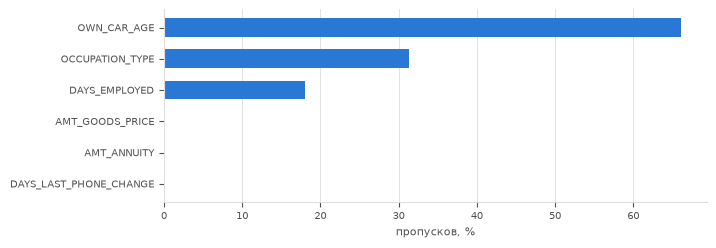

In [12]:
na = (X_eda.isna().mean() * 100).sort_values()
na = na[na > 0]

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(na.index, na.values, color=BLUE, height=0.6)
ax.set_xlabel('пропусков, %')
ax.xaxis.grid(True)
ax.set_axisbelow(True)
plt.show()

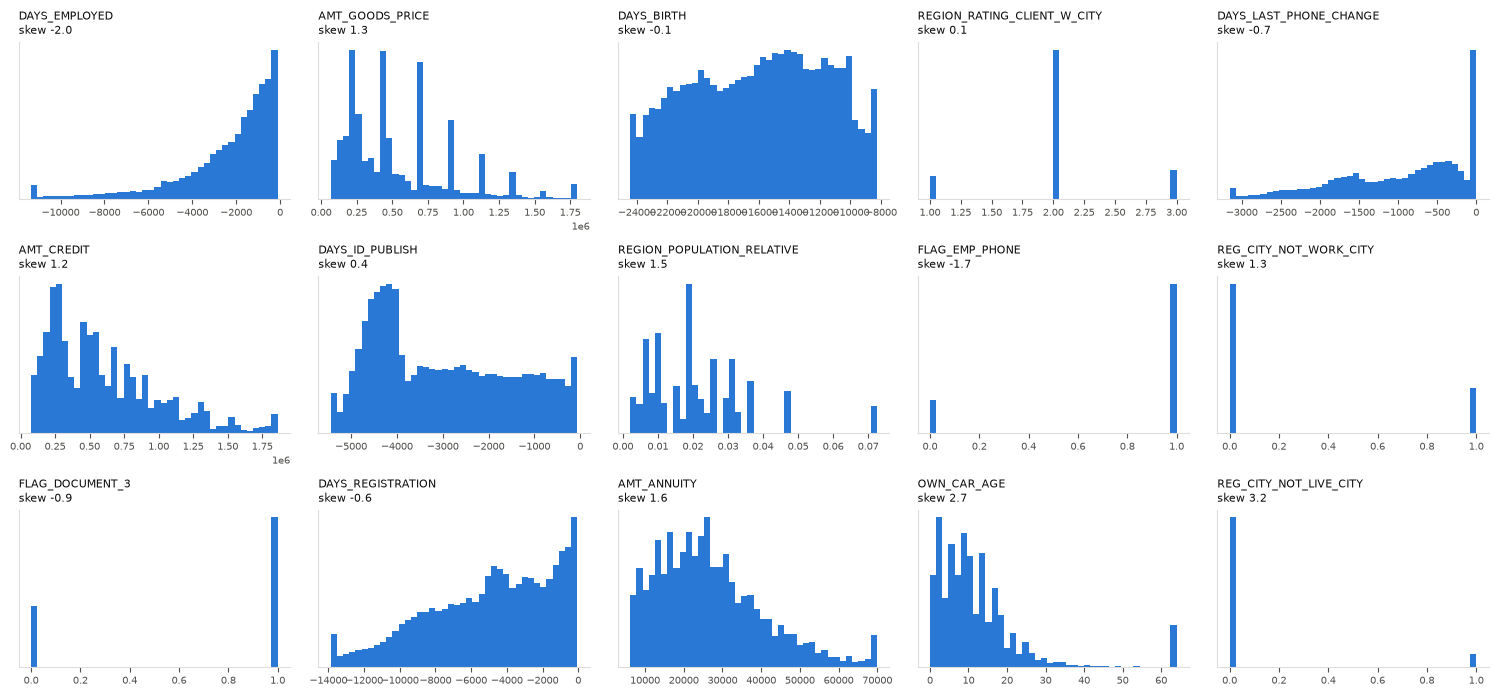

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(15, 7))
for ax, c in zip(axes.ravel(), eda_num):
    s = X_eda[c].dropna()
    ax.hist(s.clip(s.quantile(0.01), s.quantile(0.99)), bins=40, color=BLUE)
    ax.set_title(f'{c}\nskew {s.skew():.1f}', loc='left')
    ax.set_yticks([])
for ax in axes.ravel()[len(eda_num):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

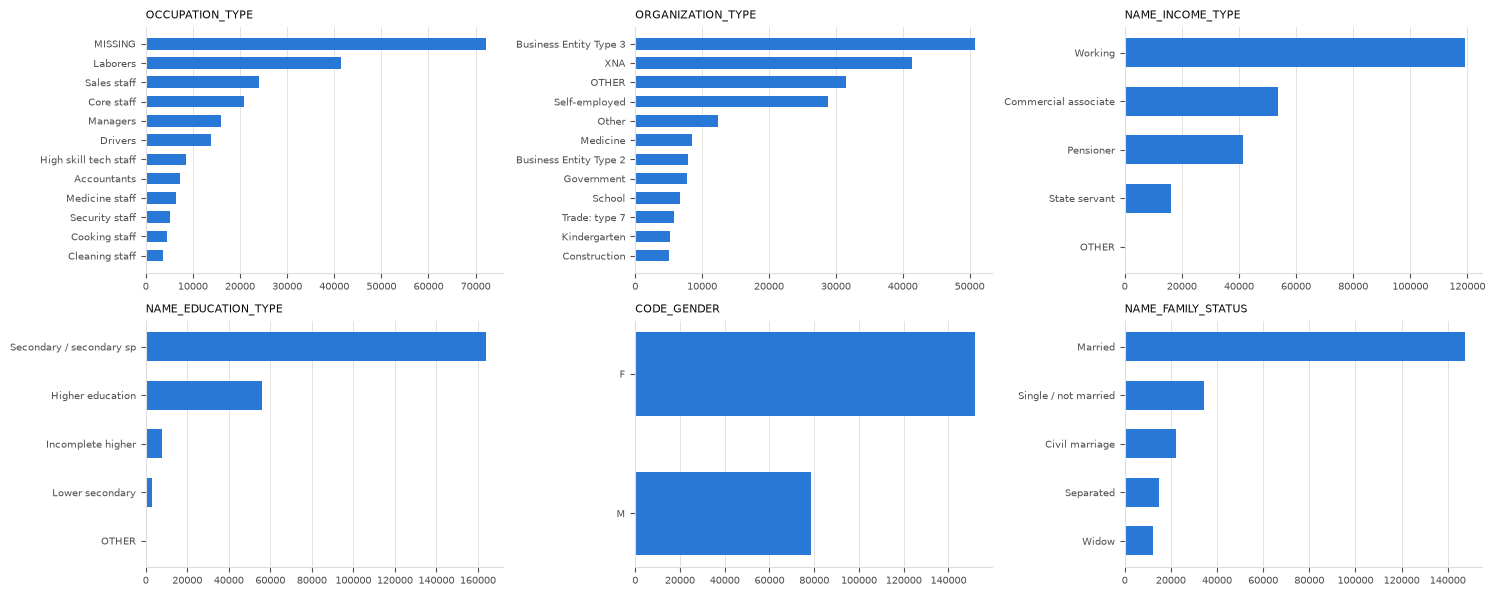

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, c in zip(axes.ravel(), eda_cat):
    vc = X_eda[c].value_counts(dropna=False).head(12).iloc[::-1]
    ax.barh([('MISSING' if pd.isna(i) else str(i))[:24] for i in vc.index],
            vc.values, color=BLUE, height=0.6)
    ax.set_title(c, loc='left')
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
for ax in axes.ravel()[len(eda_cat):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

Первая строка - `TARGET`, значения по модулю не выше 8%.

Пирсон ловит только линейную связь: у `AMT_GOODS_PRICE` корреляция −0.04 при IV 0.091.
Отбор признаков - по IV.

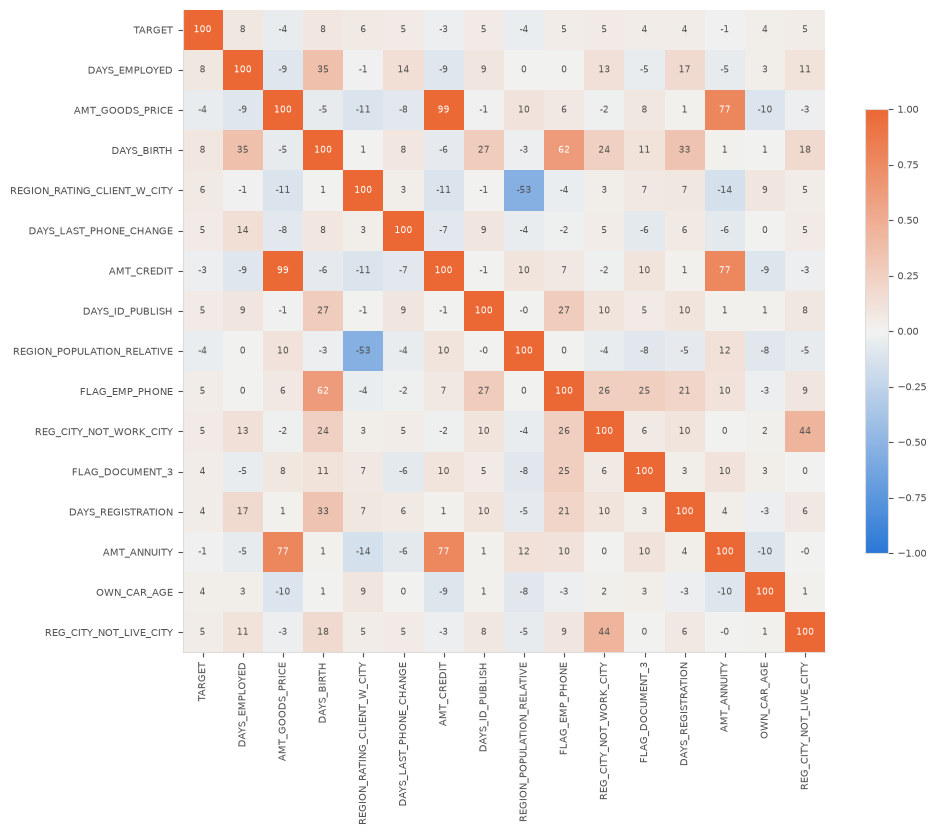

In [15]:
corr_df = X_train[eda_num].copy()
corr_df.insert(0, 'TARGET', y_train)
Corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(Corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(Corr)))
ax.set_xticklabels(Corr.columns, rotation=90)
ax.set_yticks(range(len(Corr)))
ax.set_yticklabels(Corr.columns)
for i in range(len(Corr)):
    for j in range(len(Corr)):
        r = Corr.iat[i, j]
        ax.text(j, i, f'{r*100:.0f}', ha='center', va='center', fontsize=6.5,
                color='white' if abs(r) > 0.55 else MUTED)
fig.colorbar(im, ax=ax, shrink=0.6)
fig.tight_layout()
plt.show()

## Бейзлайн

In [16]:
def fit_score(Xt, Xv, cols, name):
    model = LogisticRegression(max_iter=1000).fit(Xt[cols], y_train)
    proba = model.predict_proba(Xv[cols])[:, 1]
    auc = roc_auc_score(y_true=y_val, y_score=proba)
    print(f'{name:30s} {len(cols):3d} признаков   AUC {auc:.4f}   Gini {2*auc-1:.3f}')
    return model, auc


_, auc_49 = fit_score(X_tr_woe, X_val_woe, iv_cols, 'после IV')
model_21, auc_21 = fit_score(X_tr_woe, X_val_woe, feat_cols, 'минус жилищный блок')

после IV                        49 признаков   AUC 0.6796   Gini 0.359
минус жилищный блок             21 признаков   AUC 0.6783   Gini 0.357


`WOE = ln(good/bad)` → выше WOE, ниже риск. Регрессия предсказывает шансы дефолта,
поэтому все коэффициенты отрицательные. Выбившийся из знака = дубль.

- `AMT_CREDIT` - `r = 0.987` с `AMT_GOODS_PRICE`
- `FLAG_EMP_PHONE` - совпадает с сентинелом стажа на 99.996%, корреляционная карта не показала

In [17]:
coef_21 = pd.Series(model_21.coef_[0], index=feat_cols).sort_values()
print('выбились из знака:', list(coef_21[coef_21 > 0].index))
coef_21.round(4)

выбились из знака: ['AMT_CREDIT', 'FLAG_EMP_PHONE']


OWN_CAR_AGE                   -0.7955
AMT_GOODS_PRICE               -0.7889
FLAG_DOCUMENT_3               -0.7865
NAME_EDUCATION_TYPE           -0.7292
REGION_RATING_CLIENT_W_CITY   -0.7170
CODE_GENDER                   -0.6848
DAYS_LAST_PHONE_CHANGE        -0.6564
DAYS_EMPLOYED                 -0.5492
DAYS_ID_PUBLISH               -0.4958
DAYS_BIRTH                    -0.3935
DAYS_REGISTRATION             -0.3825
ORGANIZATION_TYPE             -0.3781
NAME_FAMILY_STATUS            -0.3429
AMT_ANNUITY                   -0.3287
REG_CITY_NOT_LIVE_CITY        -0.3243
OCCUPATION_TYPE               -0.3202
NAME_INCOME_TYPE              -0.2785
REGION_POPULATION_RELATIVE    -0.1538
REG_CITY_NOT_WORK_CITY        -0.1511
AMT_CREDIT                     0.1562
FLAG_EMP_PHONE                 1.2359
dtype: float64

## Финальный набор

Отбор продуктовый: только то, что клиент вводит сам.
`AMT_INCOME_TOTAL` возвращён при IV 0.0118 - обязателен по регуляторным требованиям
к оценке платёжеспособности и нужен знаменателем для `DTI`.

| производный | формула |
|---|---|
| `DTI` | платёж / доход · 100 |
| `TERM_MONTHS` | сумма кредита / платёж |
| `OVERPAY` | (сумма кредита − цена товара) / цена товара |

`OVERPAY > 0` - в кредит зашиты проценты, `< 0` - клиент внёс часть суммы сам.
Отдельной колонки со ставкой в датасете нет.

In [18]:
BASE_FEATURES = ['CODE_GENDER', 'NAME_FAMILY_STATUS', 'FLAG_OWN_REALTY', 'FLAG_OWN_CAR',
                 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL',
                 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY']
DERIVED = ['DTI', 'TERM_MONTHS', 'OVERPAY']
MODEL_FEATURES = BASE_FEATURES + DERIVED


def add_derived(X):
    X = X[BASE_FEATURES].copy()
    X['DTI'] = X['AMT_ANNUITY'] / X['AMT_INCOME_TOTAL'] * 100
    X['TERM_MONTHS'] = X['AMT_CREDIT'] / X['AMT_ANNUITY']
    X['OVERPAY'] = (X['AMT_CREDIT'] - X['AMT_GOODS_PRICE']) / X['AMT_GOODS_PRICE']
    return X


X_tr_fe = add_derived(X_train)
X_val_fe = add_derived(X_val)

enc = WoEEncoder()
X_tr_final = enc.fit_transform(X_tr_fe, y_train)
X_val_final = enc.transform(X_val_fe)

pd.DataFrame({'IV': enc.iv_.round(4),
              'тип': ['производный' if c in DERIVED else '' for c in enc.iv_.index]})

,IV,тип
TERM_MONTHS,0.1420,производный
DAYS_EMPLOYED,0.1116,
AMT_GOODS_PRICE,0.0906,
OCCUPATION_TYPE,0.0820,
OVERPAY,0.0728,производный
NAME_INCOME_TYPE,0.0554,
AMT_CREDIT,0.0433,
CODE_GENDER,0.0379,
AMT_ANNUITY,0.0240,
NAME_FAMILY_STATUS,0.0230,


In [19]:
model_q, auc_q = fit_score(X_tr_final, X_val_final, MODEL_FEATURES, 'анкета + производные')
_, auc_base = fit_score(X_tr_final, X_val_final, BASE_FEATURES, 'только анкета')
print(f'производные: {auc_q - auc_base:+.4f} AUC')

анкета + производные            14 признаков   AUC 0.6685   Gini 0.337
только анкета                   11 признаков   AUC 0.6453   Gini 0.291
производные: +0.0232 AUC


Величина коэффициента ≠ важность: у `FLAG_OWN_CAR` коэф −1.72 при разбросе WOE 0.08.
Важность = `|коэф · разброс WOE|`, по ней же ранжируются причины отказа.

In [20]:
importance = pd.DataFrame({
    'коэф': model_q.coef_[0],
    'разброс_WOE': X_tr_final[MODEL_FEATURES].std().values,
}, index=MODEL_FEATURES)
importance['вклад'] = (importance['коэф'] * importance['разброс_WOE']).abs()
importance.sort_values('вклад', ascending=False).round(4)

,коэф,разброс_WOE,вклад
TERM_MONTHS,-0.6489,0.3707,0.2406
DAYS_EMPLOYED,-0.6640,0.3424,0.2274
AMT_GOODS_PRICE,-0.6336,0.2951,0.1870
OVERPAY,-0.5945,0.2635,0.1566
CODE_GENDER,-0.8182,0.1905,0.1559
FLAG_OWN_CAR,-1.7179,0.0821,0.1410
OCCUPATION_TYPE,-0.4287,0.2822,0.1210
AMT_CREDIT,0.4144,0.2111,0.0875
DTI,-0.9789,0.0758,0.0742
NAME_FAMILY_STATUS,-0.4010,0.1500,0.0601


## Монотонность WOE

Немонотонный WOE не мешает предсказанию, мешает объяснимости и устойчивости.
Корзины в `bins_` проиндексованы строками - сортируем по левой границе интервала.

In [21]:
def woe_by_value(col):
    b = enc.bins_[col]
    b = b[b.index != MISSING]
    left = [float(s.split(',')[0].lstrip('(')) for s in b.index]
    return b.iloc[np.argsort(left)]


mono_num = [c for c in MODEL_FEATURES if enc.numeric_[c]]

pd.DataFrame([
    {'признак': c, 'корзин': len(woe_by_value(c)),
     'смен_направления': int((lambda d: (d[:-1] != d[1:]).sum())(
         np.sign(np.diff(woe_by_value(c)['WOE'].to_numpy())))),
     'spearman': round(spearmanr(np.arange(len(woe_by_value(c))),
                                 woe_by_value(c)['WOE'].to_numpy()).statistic, 2)}
    for c in mono_num
]).sort_values('spearman', key=abs, ascending=False)

,признак,корзин,смен_направления,spearman
0,DAYS_EMPLOYED,10,1,-0.99
5,DTI,10,1,-0.88
7,OVERPAY,8,5,-0.81
3,AMT_GOODS_PRICE,10,7,0.62
1,AMT_INCOME_TOTAL,10,4,0.48
2,AMT_CREDIT,10,3,0.32
6,TERM_MONTHS,10,7,0.16
4,AMT_ANNUITY,10,4,-0.01


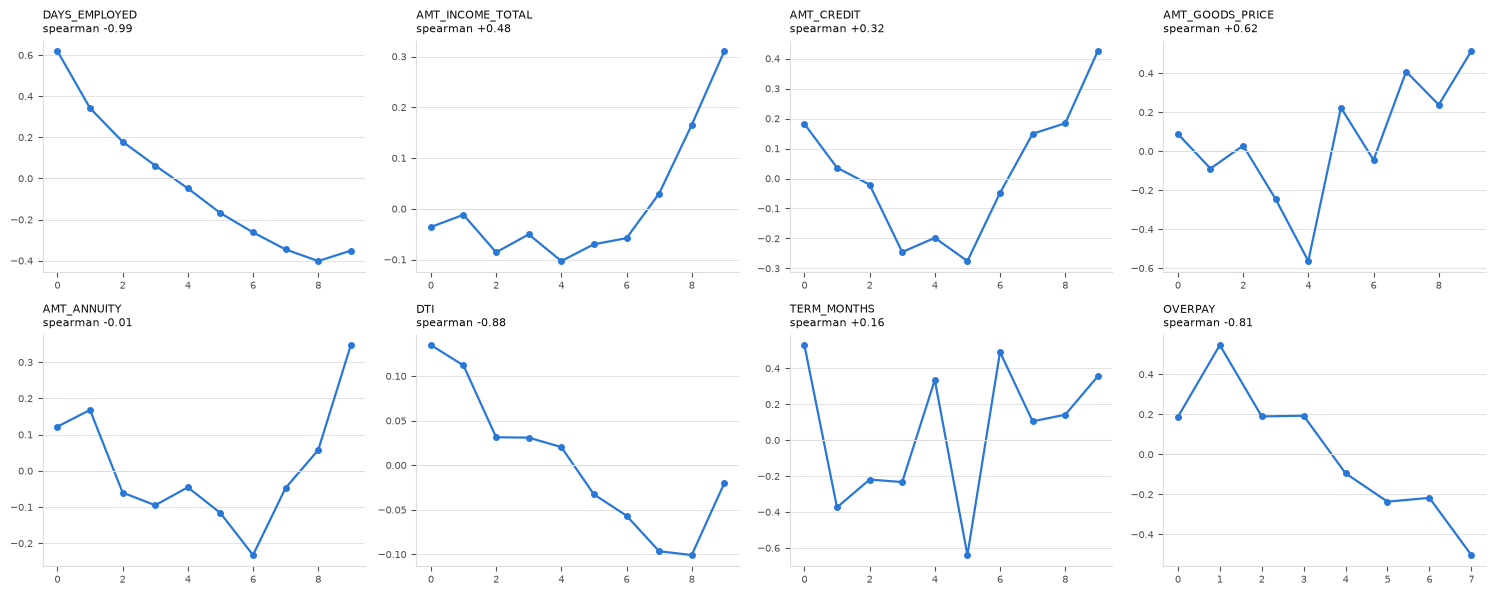

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), mono_num):
    w = woe_by_value(c)['WOE']
    ax.plot(range(len(w)), w.values, marker='o', ms=4, lw=1.6, color=BLUE)
    ax.axhline(0, lw=0.8, color=GRID)
    ax.set_title(f'{c}\nspearman {spearmanr(np.arange(len(w)), w.values).statistic:+.2f}',
                 loc='left')
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
for ax in axes.ravel()[len(mono_num):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

| | |
|---|---|
| монотонны по сути | `DAYS_EMPLOYED` (spearman −0.99), `DTI` (−0.88) |
| U-образны | `AMT_CREDIT`, `AMT_ANNUITY` - мелкие и крупные кредиты безопаснее середины |
| зигзаг | `TERM_MONTHS`, `AMT_GOODS_PRICE` - ком значений на стандартных сроках и круглых ценах |

## Монотонный биннинг

Квантильные корзины сливаются попарно, пока доля дефолтов не пойдёт монотонно
в заданном направлении.

Направление задаётся вручную. В данных крупные кредиты и платежи имеют более
низкий дефолт (LTI 10+ - 6.59% против 8.77% у LTI 2-4): такие кредиты выдавались
более проверенным клиентам, и размер займа кодирует глубину проверки.

In [23]:
DIRECTION = {
    'AMT_CREDIT': 'ascending', 'AMT_ANNUITY': 'ascending', 'AMT_GOODS_PRICE': 'ascending',
    'DTI': 'ascending', 'OVERPAY': 'ascending', 'DAYS_EMPLOYED': 'ascending',
    'AMT_INCOME_TOTAL': 'descending', 'TERM_MONTHS': 'descending',
}


def bin_stats(x, y, edges):
    idx = np.searchsorted(edges, x, side='right')
    n = np.bincount(idx, minlength=len(edges) + 1).astype(float)
    bad = np.bincount(idx, weights=y, minlength=len(edges) + 1)
    return n, np.divide(bad, n, out=np.full(n.shape, np.nan), where=n > 0)


def monotone_edges(x, y, direction, n_prebins=20, min_size=0.03):
    ok = ~np.isnan(x)
    x, y = x[ok], np.asarray(y)[ok]
    edges = np.unique(np.nanquantile(x, np.linspace(0, 1, n_prebins + 1)))[1:-1]

    while len(edges):
        n, rate = bin_stats(x, y, edges)

        small = np.flatnonzero(n < min_size * len(x))
        if len(small):
            i = small[0]
            edges = np.delete(edges, 0 if i == 0 else i - 1)
            continue

        step = np.diff(rate)
        violated = step < 0 if direction == 'ascending' else step > 0
        if not violated.any():
            break

        edges = np.delete(edges, int(np.argmin(np.where(violated, np.abs(step), np.inf))))

    return [float(e) for e in edges]

In [24]:
def build_spec(edges_fn):
    spec = {}
    for col in MODEL_FEATURES:
        if not enc.numeric_[col]:
            spec[col] = {'kind': 'cat', 'map': enc.woe_[col], 'na': 0.0}
            continue
        edges = edges_fn(col)
        idx = np.searchsorted(edges, X_tr_fe[col].to_numpy(float), side='right')
        lab = np.where(X_tr_fe[col].isna(), MISSING, idx.astype(str))
        yv_ = pd.Series(np.asarray(y_train))
        t = pd.crosstab(pd.Series(lab), yv_)
        for cls in (0, 1):
            if cls not in t.columns:
                t[cls] = 0
        k = len(t)
        good = (t[0] + 0.5) / ((y_train == 0).sum() + k * 0.5)
        bad = (t[1] + 0.5) / ((y_train == 1).sum() + k * 0.5)
        woe = np.log(good / bad).to_dict()
        spec[col] = {'kind': 'num', 'edges': edges,
                     'woe': [float(woe.get(str(i), 0.)) for i in range(len(edges) + 1)],
                     'na': float(woe.get(MISSING, 0.)),
                     'iv': float(((good - bad) * np.log(good / bad)).sum())}
    return spec


def apply_spec(spec, X):
    out = {}
    for col, r in spec.items():
        if r['kind'] == 'cat':
            out[col] = X[col].astype('object').map(
                lambda v: r['map'].get(str(v), 0.0) if pd.notna(v) else r['map'].get(MISSING, 0.0)
            ).to_numpy(float)
        else:
            v = X[col].to_numpy(float)
            w = np.asarray(r['woe'])[np.searchsorted(r['edges'], v, side='right')]
            out[col] = np.where(np.isnan(v), r['na'], w)
    return pd.DataFrame(out, index=X.index)


spec_mono = build_spec(lambda c: monotone_edges(
    X_tr_fe[c].to_numpy(float), y_train, DIRECTION[c]))

pd.DataFrame([
    {'признак': c,
     'корзин': len(spec_mono[c]['edges']) + 1,
     'IV_моно': round(spec_mono[c]['iv'], 4),
     'IV_квантильный': round(enc.iv_[c], 4)}
    for c in MODEL_FEATURES if enc.numeric_[c]
])

,признак,корзин,IV_моно,IV_квантильный
0,DAYS_EMPLOYED,13,0.1140,0.1116
1,AMT_INCOME_TOTAL,6,0.0115,0.0118
2,AMT_CREDIT,5,0.0055,0.0433
3,AMT_GOODS_PRICE,3,0.0026,0.0906
4,AMT_ANNUITY,5,0.0058,0.0240
5,DTI,6,0.0063,0.0057
6,TERM_MONTHS,4,0.0406,0.1420
7,OVERPAY,7,0.0729,0.0728


In [25]:
W_tr, W_val = apply_spec(spec_mono, X_tr_fe), apply_spec(spec_mono, X_val_fe)
model_mono = LogisticRegression(max_iter=1000).fit(W_tr[MODEL_FEATURES], y_train)
proba = model_mono.predict_proba(W_val[MODEL_FEATURES])[:, 1]
auc_mono = roc_auc_score(y_true=y_val, y_score=proba)

bad_sign = [c for c, v in zip(MODEL_FEATURES, model_mono.coef_[0]) if v > 0]

print(f'{"квантильный, 10 корзин":26s} AUC {auc_q:.4f}  Gini {2*auc_q-1:.4f}')
print(f'{"монотонный":26s} AUC {auc_mono:.4f}  Gini {2*auc_mono-1:.4f}')
print(f'коэффициентов с неверным знаком: {bad_sign or "нет"}')

квантильный, 10 корзин     AUC 0.6685  Gini 0.3370
монотонный                 AUC 0.6539  Gini 0.3078
коэффициентов с неверным знаком: нет


Монотонность стоит около 0.008 AUC и убирает перевёрнутые знаки у `AMT_CREDIT`
и `AMT_INCOME_TOTAL`.

In [26]:
c = 'TERM_MONTHS'
edges = spec_mono[c]['edges']
idx = np.searchsorted(edges, X_tr_fe[c].to_numpy(float), side='right')
t = pd.DataFrame({'bin': idx, 'y': y_train}).groupby('bin').agg(n=('y', 'size'), bad=('y', 'mean'))
t['доля_%'] = (t['n'] / len(X_tr_fe) * 100).round(1)
t['дефолт_%'] = (t['bad'] * 100).round(2)
t['WOE'] = [round(spec_mono[c]['woe'][i], 3) for i in t.index]
print('границы:', [round(e, 1) for e in edges])
t[['n', 'доля_%', 'дефолт_%', 'WOE']]

границы: [22.0, 31.0, 34.5]


,n,доля_%,дефолт_%,WOE
bin,,,,
0,138365,60.0,9.23,-0.147
1,57652,25.0,6.64,0.211
2,23069,10.0,6.09,0.302
3,11542,5.0,5.29,0.452


`TERM_MONTHS` теряет в IV относительно свободного биннинга - его сила была
в немонотонности. Читается однозначно: длиннее срок, ниже платёж, ниже риск.
Причина отказа формулируется как «срок слишком короткий для такой суммы».

In [27]:
order = np.argsort(proba)
yv = np.asarray(y_val)

print(f'базовый уровень дефолта {yv.mean():.2%}\n')
for rate in (0.9, 0.8, 0.7, 0.6, 0.5):
    bad = yv[order[:int(len(yv) * rate)]].mean()
    print(f'  одобряем {rate:.0%}  ->  дефолт {bad:.2%}  ({bad / yv.mean() - 1:+.0%})')

базовый уровень дефолта 8.07%

  одобряем 90%  ->  дефолт 6.91%  (-14%)
  одобряем 80%  ->  дефолт 6.22%  (-23%)
  одобряем 70%  ->  дефолт 5.70%  (-29%)
  одобряем 60%  ->  дефолт 5.23%  (-35%)
  одобряем 50%  ->  дефолт 4.84%  (-40%)


## Кредитная история

Три агрегата из `bureau.csv`. Клиент называет их по памяти, обращение в бюро
не требуется.

| признак | что это |
|---|---|
| `N_ACTIVE_CREDITS` | сколько кредитов открыто сейчас |
| `CURRENT_DEBT` | суммарный остаток долга по ним |
| `FIRST_CREDIT_DAYS` | когда взят первый кредит, дней до заявки |

In [28]:
bureau = pd.read_csv('../datasets/bureau.csv',
                     usecols=['SK_ID_CURR', 'CREDIT_ACTIVE', 'AMT_CREDIT_SUM_DEBT',
                              'DAYS_CREDIT'])
active = bureau[bureau['CREDIT_ACTIVE'] == 'Active']

agg = pd.DataFrame({
    'N_ACTIVE_CREDITS': active.groupby('SK_ID_CURR').size(),
    'CURRENT_DEBT': active.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].sum().clip(lower=0),
    'FIRST_CREDIT_DAYS': bureau.groupby('SK_ID_CURR')['DAYS_CREDIT'].min(),
}).reindex(bureau['SK_ID_CURR'].unique())


def attach_bureau(X):
    ids = clean_df.loc[X.index, 'SK_ID_CURR']
    out = X.copy()
    for col in agg.columns:
        out[col] = agg.reindex(ids)[col].to_numpy()
    out['N_ACTIVE_CREDITS'] = out['N_ACTIVE_CREDITS'].fillna(0)
    return out


X_tr_cr, X_val_cr = attach_bureau(X_tr_fe), attach_bureau(X_val_fe)

print('пропусков в bureau.csv, %:')
print((bureau[['AMT_CREDIT_SUM_DEBT', 'DAYS_CREDIT']].isna().mean() * 100).round(1).to_string())
print('отрицательных значений долга:', int((bureau['AMT_CREDIT_SUM_DEBT'] < 0).sum()))

пропусков в bureau.csv, %:
AMT_CREDIT_SUM_DEBT    15.0
DAYS_CREDIT             0.0
отрицательных значений долга: 8418


Два случая, которые нельзя склеивать: истории нет вовсе и история есть,
но активных кредитов нет.

In [29]:
d = X_tr_cr['CURRENT_DEBT']
groups = {
    'истории нет': d.isna(),
    'долг погашен': d == 0,
    'долг до 200 тыс': (d > 0) & (d <= 200_000),
    'долг 200 тыс - 1 млн': (d > 200_000) & (d <= 1_000_000),
    'долг свыше 1 млн': d > 1_000_000,
}

pd.DataFrame([
    {'группа': name, 'клиентов': int(m.sum()),
     'дефолт_%': round(y_train[m.to_numpy()].mean() * 100, 2)}
    for name, m in groups.items()
])

,группа,клиентов,дефолт_%
0,истории нет,67619,7.88
1,долг погашен,25098,5.72
2,долг до 200 тыс,45357,7.97
3,долг 200 тыс - 1 млн,58965,8.89
4,долг свыше 1 млн,33589,8.93


In [30]:
CREDIT_HISTORY = ['N_ACTIVE_CREDITS', 'CURRENT_DEBT', 'FIRST_CREDIT_DAYS']
DIRECTION.update({c: 'ascending' for c in CREDIT_HISTORY})
FEATURES_CR = MODEL_FEATURES + CREDIT_HISTORY


def build_spec_on(X, cols, edges_fn):
    spec = {}
    for col in cols:
        if col in cat_cols:
            lab = X[col].astype('object').where(X[col].notna(), MISSING).astype(str)
            t = pd.crosstab(pd.Series(lab.to_numpy()), pd.Series(np.asarray(y_train)))
            for cls in (0, 1):
                if cls not in t.columns:
                    t[cls] = 0
            k = len(t)
            good = (t[0] + 0.5) / ((y_train == 0).sum() + k * 0.5)
            bad = (t[1] + 0.5) / ((y_train == 1).sum() + k * 0.5)
            w = np.log(good / bad)
            spec[col] = {'kind': 'cat', 'map': w.to_dict(), 'na': float(w.get(MISSING, 0.)),
                         'iv': float(((good - bad) * w).sum())}
            continue
        edges = edges_fn(X, col)
        idx = np.searchsorted(edges, X[col].to_numpy(float), side='right')
        lab = np.where(X[col].isna(), MISSING, idx.astype(str))
        t = pd.crosstab(pd.Series(lab), pd.Series(np.asarray(y_train)))
        for cls in (0, 1):
            if cls not in t.columns:
                t[cls] = 0
        k = len(t)
        good = (t[0] + 0.5) / ((y_train == 0).sum() + k * 0.5)
        bad = (t[1] + 0.5) / ((y_train == 1).sum() + k * 0.5)
        w = np.log(good / bad).to_dict()
        spec[col] = {'kind': 'num', 'edges': edges,
                     'woe': [float(w.get(str(i), 0.)) for i in range(len(edges) + 1)],
                     'na': float(w.get(MISSING, 0.)),
                     'iv': float(((good - bad) * np.log(good / bad)).sum())}
    return spec


spec_cr = build_spec_on(X_tr_cr, FEATURES_CR,
                        lambda X, c: monotone_edges(X[c].to_numpy(float), y_train, DIRECTION[c]))

pd.DataFrame([{'признак': c, 'IV': round(spec_cr[c]['iv'], 4)} for c in FEATURES_CR]
             ).sort_values('IV', ascending=False).head(8)

,признак,IV
6,DAYS_EMPLOYED,0.1140
4,OCCUPATION_TYPE,0.0820
16,FIRST_CREDIT_DAYS,0.0763
13,OVERPAY,0.0729
5,NAME_INCOME_TYPE,0.0554
12,TERM_MONTHS,0.0406
0,CODE_GENDER,0.0379
14,N_ACTIVE_CREDITS,0.0248


In [31]:
W_tr, W_val = apply_spec(spec_cr, X_tr_cr), apply_spec(spec_cr, X_val_cr)
model_cr = LogisticRegression(max_iter=1000).fit(W_tr[FEATURES_CR], y_train)
auc_cr = roc_auc_score(y_true=y_val, y_score=model_cr.predict_proba(W_val[FEATURES_CR])[:, 1])

only_debt = MODEL_FEATURES + ['CURRENT_DEBT']
m_d = LogisticRegression(max_iter=1000).fit(W_tr[only_debt], y_train)
auc_d = roc_auc_score(y_true=y_val, y_score=m_d.predict_proba(W_val[only_debt])[:, 1])

pd.DataFrame([
    {'набор': '14 анкетных', 'ROC-AUC': round(auc_mono, 4), 'Gini': round(2 * auc_mono - 1, 4)},
    {'набор': '+ только долг', 'ROC-AUC': round(auc_d, 4), 'Gini': round(2 * auc_d - 1, 4)},
    {'набор': '+ все три', 'ROC-AUC': round(auc_cr, 4), 'Gini': round(2 * auc_cr - 1, 4)},
])

,набор,ROC-AUC,Gini
0,14 анкетных,0.6539,0.3078
1,+ только долг,0.6598,0.3195
2,+ все три,0.6815,0.3630


Основной вклад даёт давность первого кредита, не размер долга. Замер сделан
на фактических значениях из `bureau.csv`: заявитель долг занизит, а давность
вспомнит приблизительно, поэтому в проде блок даст меньше.

## PR-AUC и калибровка

Дефолтов 8% (то есть имеется сильный дисбаланс классов), поэтому ROC-AUC может выглядеть оптимистичнее при плохой точности.
PR-AUC позволяет смотреть только на дефолтников чтобы сделать нужные выводы.


Калибровка нужна для ценообразования: если модель говорит PD 5%, дефолтить
должны 5%. Для решения одобрить/отказать достаточно ранжирования, для ставки - нет.

In [32]:
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             brier_score_loss)
from sklearn.calibration import calibration_curve

y_true = np.asarray(y_val)
base_rate = y_true.mean()

models = {
    'квантильный': model_q.predict_proba(X_val_final[MODEL_FEATURES])[:, 1],
    'монотонный': proba,
}

pd.DataFrame([
    {'модель': name,
     'ROC-AUC': round(roc_auc_score(y_true, p), 4),
     'PR-AUC': round(average_precision_score(y_true, p), 4),
     'PR-AUC базовый': round(base_rate, 4),
     'лифт': round(average_precision_score(y_true, p) / base_rate, 2),
     'Brier': round(brier_score_loss(y_true, p), 5)}
    for name, p in models.items()
])

,модель,ROC-AUC,PR-AUC,PR-AUC базовый,лифт,Brier
0,квантильный,0.6685,0.1562,0.0807,1.93,0.07185
1,монотонный,0.6539,0.1489,0.0807,1.84,0.07222


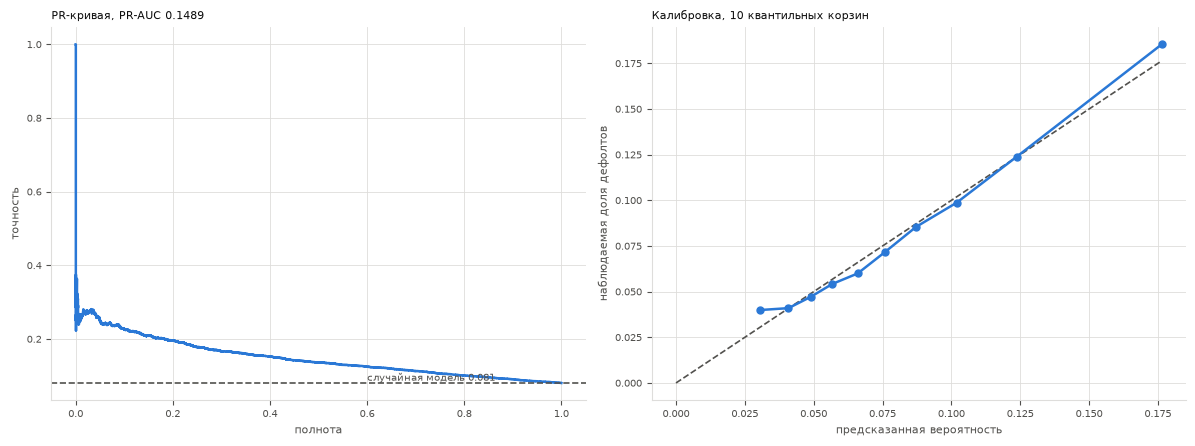

In [33]:
prec, rec, _ = precision_recall_curve(y_true, proba)
frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rec, prec, lw=1.8, color=BLUE)
axes[0].axhline(base_rate, lw=1.2, ls='--', color=MUTED)
axes[0].text(0.6, base_rate + 0.006, f'случайная модель {base_rate:.3f}',
             fontsize=7, color=MUTED)
axes[0].set_xlabel('полнота')
axes[0].set_ylabel('точность')
axes[0].set_title(f'PR-кривая, PR-AUC {average_precision_score(y_true, proba):.4f}',
                  loc='left')
axes[0].grid(True)
axes[0].set_axisbelow(True)

axes[1].plot([0, mean_pred.max()], [0, mean_pred.max()], lw=1.2, ls='--', color=MUTED)
axes[1].plot(mean_pred, frac_pos, marker='o', ms=5, lw=1.8, color=BLUE)
axes[1].set_xlabel('предсказанная вероятность')
axes[1].set_ylabel('наблюдаемая доля дефолтов')
axes[1].set_title('Калибровка, 10 квантильных корзин', loc='left')
axes[1].grid(True)
axes[1].set_axisbelow(True)

fig.tight_layout()
plt.show()

In [34]:
calib = pd.DataFrame({
    'предсказано': mean_pred.round(4),
    'наблюдается': frac_pos.round(4),
    'отклонение': (frac_pos - mean_pred).round(4),
})
ece = float(np.abs(frac_pos - mean_pred).mean())
print(f'средняя ошибка калибровки (ECE): {ece:.4f}')
print(f'средний предсказанный PD {proba.mean():.4f} против фактического {base_rate:.4f}')
calib

средняя ошибка калибровки (ECE): 0.0038
средний предсказанный PD 0.0808 против фактического 0.0807


,предсказано,наблюдается,отклонение
0,0.0305,0.0399,0.0094
1,0.0408,0.0410,0.0001
2,0.0489,0.0471,-0.0018
3,0.0568,0.0542,-0.0026
4,0.0660,0.0600,-0.0060
5,0.0758,0.0715,-0.0042
6,0.0872,0.0855,-0.0017
7,0.1019,0.0987,-0.0032
8,0.1238,0.1239,0.0002
9,0.1764,0.1854,0.0090


In [35]:
rows = []
for k in (0.05, 0.10, 0.20, 0.30, 0.50):
    n = int(len(proba) * k)
    idx = np.argsort(-proba)[:n]
    rows.append({'доля_худших': f'{k:.0%}',
                 'точность': round(y_true[idx].mean(), 4),
                 'полнота': round(y_true[idx].sum() / y_true.sum(), 4),
                 'лифт': round(y_true[idx].mean() / base_rate, 2)})

pd.DataFrame(rows)

,доля_худших,точность,полнота,лифт
0,5%,0.2160,0.1337,2.68
1,10%,0.1854,0.2296,2.30
2,20%,0.1547,0.3832,1.92
3,30%,0.1360,0.5055,1.68
4,50%,0.1130,0.7000,1.40


## Итоги

| этап | признаков | AUC | Gini |
|---|---|---|---|
| после `IV > 0.02` | 49 | 0.6796 | 0.359 |
| минус жилищный блок | 21 | 0.6783 | 0.357 |
| только анкета | 11 | 0.6453 | 0.291 |
| анкета + производные | 14 | 0.6685 | 0.337 |
| монотонный биннинг | 14 | 0.6539 | 0.308 |
| **+ кредитная история** | **17** | **0.6815** | **0.363** |

При одобрении 60% заявок дефолт падает с 8.07% до 5.2%.

Что стоит держать в голове:

- Selective labels: в датасете только выданные кредиты. Модель валидна на области,
  похожей на одобренных. В данных крупные кредиты имеют более низкий дефолт, потому
  что их выдавали более проверенным клиентам - направление монотонности задано
  вручную, иначе модель выучивает обратную зависимость.
- Out-of-time валидация невозможна, календарной даты в данных нет.
- Заявленный доход почти не предсказывает дефолт: у нижних 70% распределения
  уровень плоский, 8.2-8.9%. Работает только в отношениях.
- `OVERPAY` назначает банк по своей оценке риска. Требует проверки, известна ли
  наценка клиенту до подачи заявки.
- `CODE_GENDER` запрещён в кредитных решениях (ЕС, ECOA), из финальной модели убрать.
- `FLAG_OWN_REALTY` не несёт сигнала: IV 0.0003, дефолт 8.32% против 7.96%.

Дальше: причины отказа через потерянные баллы, сервис.